In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('Sample_Superstore.csv', encoding='latin-1')

In [18]:
# this will give me the top 5 rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
# it will tell the number of rows and number of columns in the dataset
print("Shape of Dataset: ", df.shape)

Shape of Dataset:  (9994, 21)


In [20]:
# this will give us the columns name into a list
print("\nColumn Names:\n", df.columns.tolist())


Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [21]:
# this will tell us the data type of each column
print("Data Types:\n",df.dtypes)

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [25]:
# this will give us all the missing values sum
print("Missing Values in each column:\n",df.isnull().sum())

Missing Values in each column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [23]:
# this will give us min,max,average and standard deviation etc
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [26]:
# this will give us the sum of the duplicate rows
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


In [27]:
# this will drop the duplicates if present in the dataset
df = df.drop_duplicates()

In [28]:
# lets now fix the order date and ship date to proper datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [29]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [32]:
# extracting useful column from date which are year and month from order date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')

df[['Order Date', 'Order Year', 'Order Month', 'Order Month Name']].head()

,Order Date,Order Year,Order Month,Order Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [33]:
# which category has the most sales:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Sales by Category: ", category_sales)

Sales by Category:  Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [36]:
# which region is most profitable
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("Profit By Region: ",region_profit)

Profit By Region:  Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [37]:
# top 10 products with the highest sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
print("Top 10 Products: ",top_products)

Top 10 Products:  Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
                                                                                 ...    
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                                 7.700
Grip Seal Envelopes                                                                7.072
Xerox 20                                                                           6.480
Avery 5                                                                            5.760
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac               

In [38]:
# yearly sales trend
yearly_sales = df.groupby('Order Year')['Sales'].sum()
print("Yearly Sales: ",yearly_sales)

Yearly Sales:  Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_5932\455324377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')


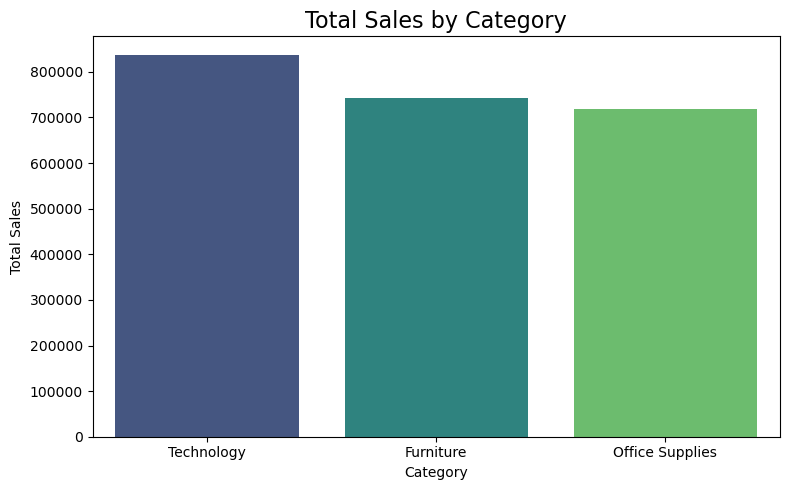

In [40]:
# sales by category bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_5932\3712580942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette='coolwarm')


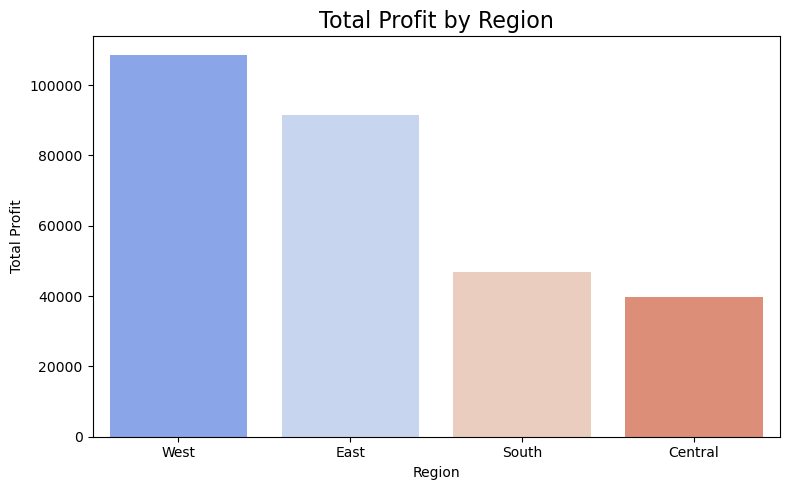

In [41]:
# Profit by region bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='coolwarm')
plt.title('Total Profit by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

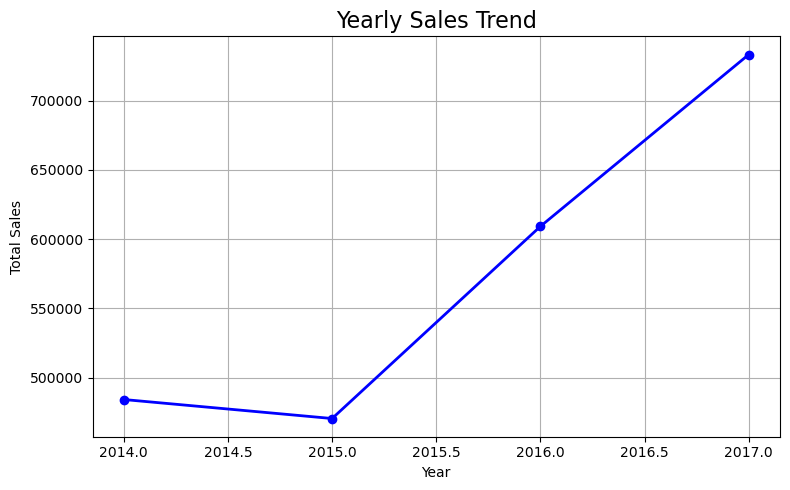

In [42]:
# yearly sales trend
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='blue', linewidth=2)
plt.title('Yearly Sales Trend', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

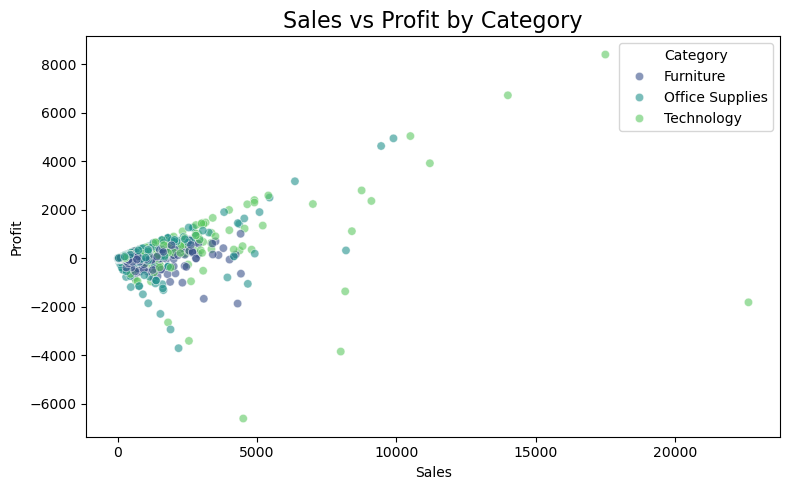

In [43]:
# sales vs profit scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category', palette='viridis', alpha=0.6)
plt.title('Sales vs Profit by Category', fontsize=16)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

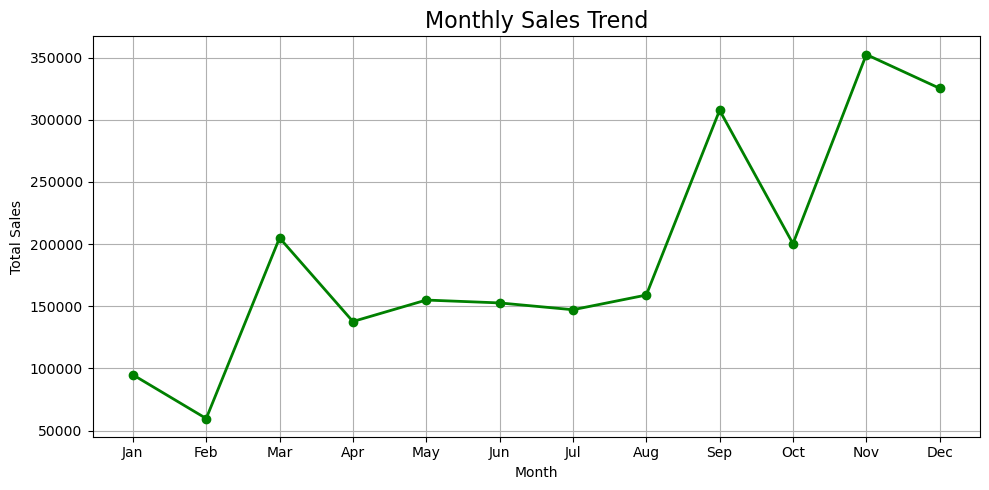

In [44]:
# monthly sales trend line chart
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_5932\733581430.py:6: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_5932\733581430.py:6: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


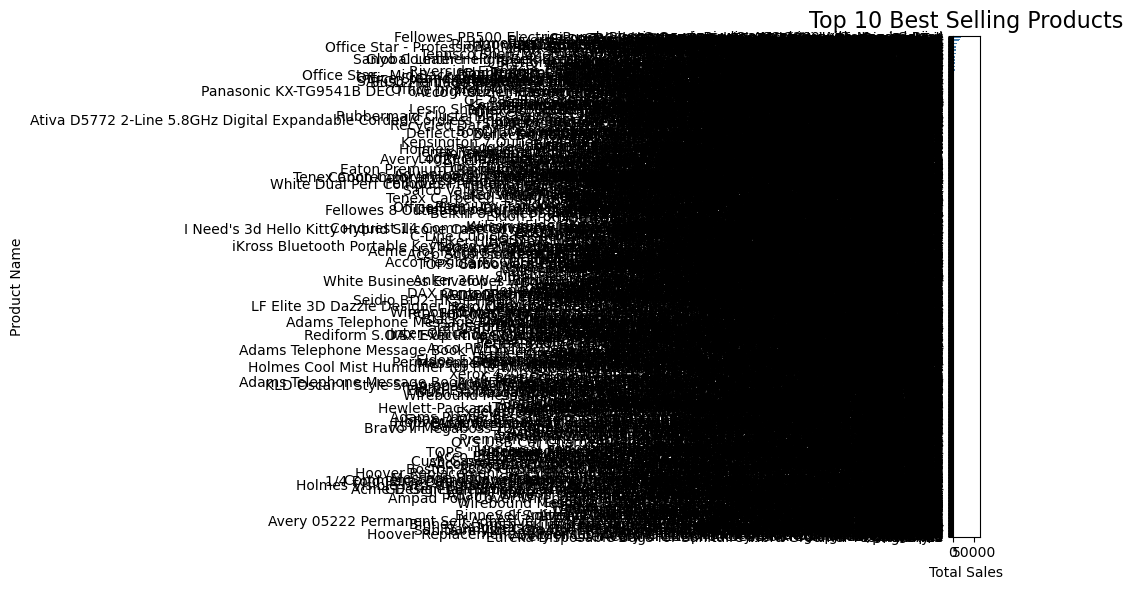

In [45]:
# top 10 products horizontal bar chart
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Best Selling Products', fontsize=16)
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

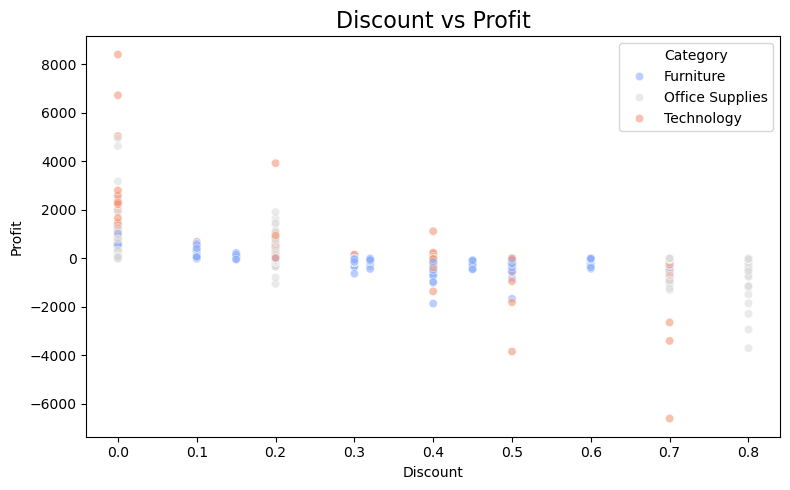

In [46]:
# discount vs profit 
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, hue='Category', palette='coolwarm', alpha=0.6)
plt.title('Discount vs Profit', fontsize=16)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

In [47]:
print("=" * 60)
print("       SUPERSTORE SALES ANALYSIS - KEY INSIGHTS")
print("=" * 60)

print("""
1. 🏆 Technology is the highest selling Category
2. 💰 West Region generates the highest Profit
3. 📈 Sales have grown consistently every year
4. 🛍️ November and December have highest monthly sales
           (Holiday Season Effect!)
5. ⚠️  Higher Discounts are directly hurting Profits
           (Negative Correlation between Discount & Profit)
6. 📦 Top selling products are mostly Technology items
""")

print("=" * 60)
print("Analysis Complete! ✅")
print("=" * 60)

       SUPERSTORE SALES ANALYSIS - KEY INSIGHTS

1. 🏆 Technology is the highest selling Category
2. 💰 West Region generates the highest Profit
3. 📈 Sales have grown consistently every year
4. 🛍️ November and December have highest monthly sales
           (Holiday Season Effect!)
5. ⚠️  Higher Discounts are directly hurting Profits
           (Negative Correlation between Discount & Profit)
6. 📦 Top selling products are mostly Technology items

Analysis Complete! ✅
